# Unsupervised Exploration

1.Load the Palmer Penguins dataset (sns.load_dataset("penguins")).

2.Clean the data: handle missing values, examine distributions, and note any anomalies.

3.Select the numeric features and scale them with StandardScaler.

4.Apply PCA (2 components) and t-SNE (2 components, random_state=42). Create a side-by-side plot colored by actual species.

5.Apply K-Means (k=3) and DBSCAN (experiment with at least 2 eps/min_samples combos) to the scaled data.

6.Evaluate each clustering result with the silhouette score.

7.Compare your best clustering labels to the actual species using adjusted Rand score and normalized mutual information. Visualize the comparison on a PCA projection.

8.In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail?

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import (silhouette_score,adjusted_rand_score,normalized_mutual_info_score)

In [2]:
penguins=sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
penguins.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [5]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


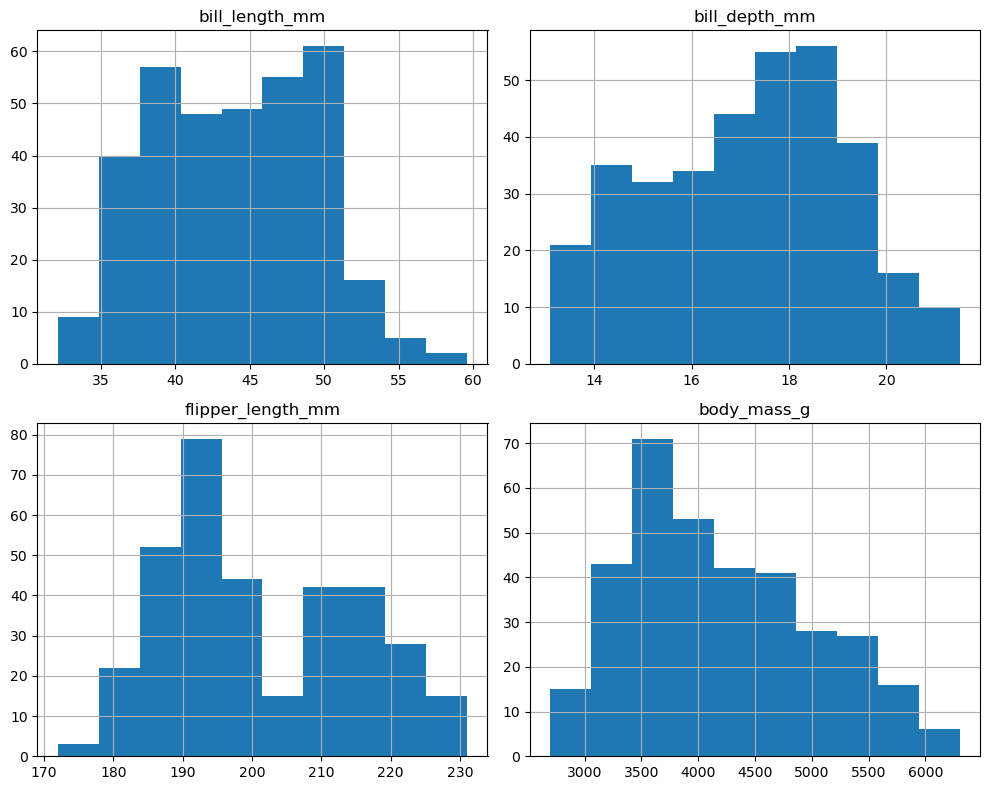

In [6]:
penguins.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

In [7]:
penguins_clean=penguins.dropna()
penguins_clean.shape

(333, 7)

In [8]:
numeric_features = penguins_clean.select_dtypes(include=np.number)
numeric_features.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [9]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_features)

In [10]:
pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result,columns=["PC1", "PC2"])

pca_df["species"] = penguins_clean["species"].values

In [11]:
tsne = TSNE(n_components=2,random_state=42,perplexity=30)

tsne_result = tsne.fit_transform(scaled_data)

tsne_df = pd.DataFrame(tsne_result,columns=["TSNE1", "TSNE2"])

tsne_df["species"] = penguins_clean["species"].values

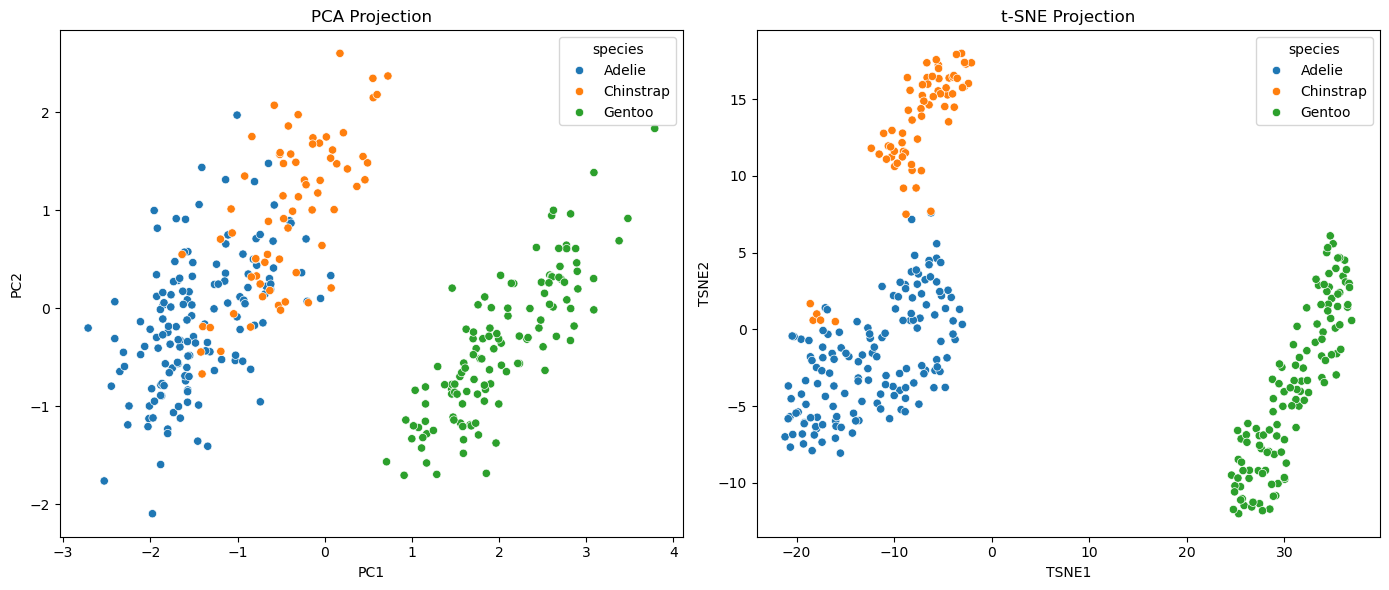

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# PCA Plot
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="species",
    ax=axes[0]
)

axes[0].set_title("PCA Projection")

# t-SNE Plot
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="species",
    ax=axes[1]
)

axes[1].set_title("t-SNE Projection")

plt.tight_layout()
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3,random_state=42,n_init=10)

kmeans_labels = kmeans.fit_predict(scaled_data)

kmeans_silhouette = silhouette_score(scaled_data,kmeans_labels)

print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.446192544665462


C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [14]:
dbscan1 = DBSCAN(eps=0.5,min_samples=5)

dbscan1_labels = dbscan1.fit_predict(scaled_data)

# Ignore noise points for silhouette score
mask1 = dbscan1_labels != -1

dbscan1_silhouette = silhouette_score(scaled_data[mask1],dbscan1_labels[mask1])

print("DBSCAN 1 Silhouette Score:", dbscan1_silhouette)

DBSCAN 1 Silhouette Score: 0.42232130626250697


In [15]:
dbscan2 = DBSCAN(eps=0.8,min_samples=4)

dbscan2_labels = dbscan2.fit_predict(scaled_data)

mask2 = dbscan2_labels != -1

dbscan2_silhouette = silhouette_score(scaled_data[mask2],dbscan2_labels[mask2])

print("DBSCAN 2 Silhouette Score:", dbscan2_silhouette)

DBSCAN 2 Silhouette Score: 0.5350699309975018


In [16]:
true_labels = penguins_clean["species"]

kmeans_ari = adjusted_rand_score(true_labels,kmeans_labels)

kmeans_nmi = normalized_mutual_info_score(true_labels,kmeans_labels)

print("K-Means ARI:", kmeans_ari)
print("K-Means NMI:", kmeans_nmi)

K-Means ARI: 0.7994209859673324
K-Means NMI: 0.7899317532789121


In [17]:
dbscan1_ari = adjusted_rand_score(true_labels,dbscan1_labels)

dbscan1_nmi = normalized_mutual_info_score(true_labels,dbscan1_labels)

print("DBSCAN 1 ARI:", dbscan1_ari)
print("DBSCAN 1 NMI:", dbscan1_nmi)

DBSCAN 1 ARI: 0.6633997983653745
DBSCAN 1 NMI: 0.6634308566924778


In [18]:
dbscan2_ari = adjusted_rand_score(true_labels,dbscan2_labels)

dbscan2_nmi = normalized_mutual_info_score(true_labels,dbscan2_labels)

print("DBSCAN 2 ARI:", dbscan2_ari)
print("DBSCAN 2 NMI:", dbscan2_nmi)

DBSCAN 2 ARI: 0.6397702152241611
DBSCAN 2 NMI: 0.7264548192323508


In [19]:
pca_vis = pd.DataFrame(pca_result,columns=["PC1", "PC2"])

pca_vis["Cluster"] = kmeans_labels
pca_vis["Species"] = true_labels.values

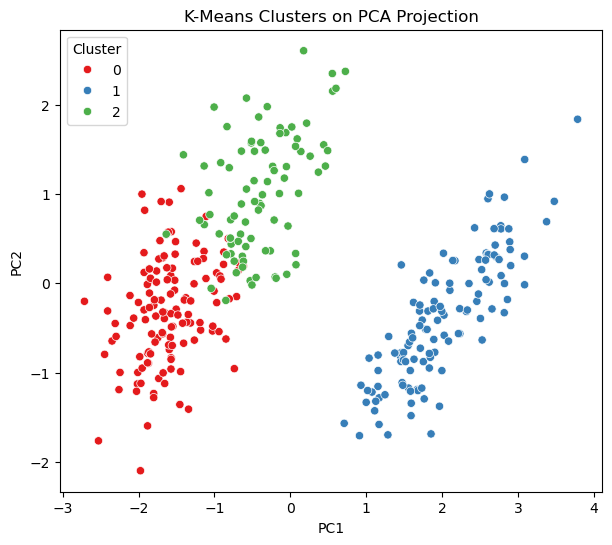

In [20]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=pca_vis,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set1"
)

plt.title("K-Means Clusters on PCA Projection")
plt.show()

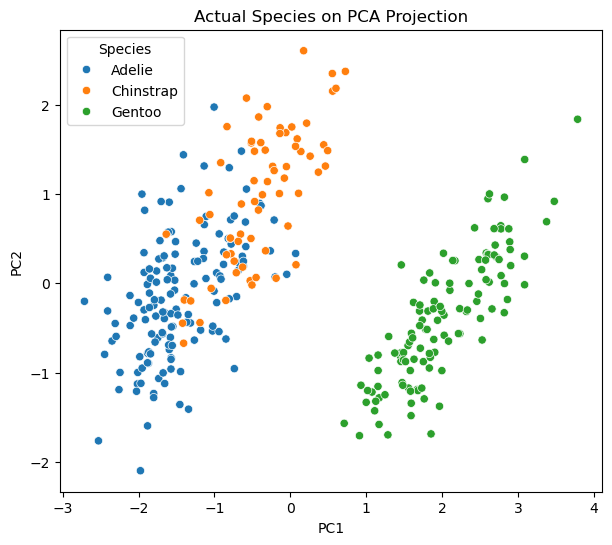

In [21]:
plt.figure(figsize=(7,6))

sns.scatterplot(
    data=pca_vis,
    x="PC1",
    y="PC2",
    hue="Species"
)

plt.title("Actual Species on PCA Projection")
plt.show()

### Unsupervised Learning Summary

In this task, unsupervised learning techniques were used to explore the Palmer Penguins dataset and determine whether natural clusters matched the real penguin species.

The dataset was first cleaned by removing missing values. Numeric features were standardized because clustering and dimensionality reduction methods are sensitive to feature scale.

PCA and t-SNE were applied to reduce the dataset into two dimensions for visualization. PCA showed that some species formed relatively separate groups, while t-SNE created clearer nonlinear separations between clusters.

K-Means clustering with k=3 performed well because the dataset naturally contains three penguin species. The silhouette score indicated reasonably strong cluster separation. The Adjusted Rand Index (ARI) and Normalized Mutual Information (NMI) also showed strong agreement between predicted clusters and actual species labels.

DBSCAN produced mixed results. Some parameter settings identified meaningful groups, but others labeled many points as noise or merged clusters incorrectly. This happened because DBSCAN is sensitive to density differences and parameter choices.

Overall, unsupervised learning methods were able to recover much of the species structure in the dataset. However, overlap between similar species and feature similarities caused some clustering mistakes, especially for density-based clustering methods like DBSCAN.

# Supervised Model Pipeline

1.Prepare the full dataset for supervised classification: target = species, features = all other columns.

2.Drop rows with missing values using dropna(), then build a preprocessing pipeline using ColumnTransformer:
- Numeric features: scale (StandardScaler).
  
- Categorical features: one-hot encode (OneHotEncoder).

3.Train and evaluate at least 3 different models (e.g., LogisticRegression, RandomForest, SVC) using stratified 5-fold cross-validation. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.

4.Select the best model based on F1 score.

5.Define a hyperparameter grid (at least 3 parameters) and run GridSearchCV with stratified 5-fold CV.

6.Report the best parameters, best CV score, and compare with the default model performance.

In [22]:
from sklearn.model_selection import (train_test_split,cross_validate,StratifiedKFold,GridSearchCV)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (StandardScaler,OneHotEncoder)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [23]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [24]:
penguins = penguins.dropna()
penguins.shape

(333, 7)

In [25]:
X = penguins.drop("species", axis=1)
y = penguins["species"]

In [26]:
numeric_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(exclude=np.number).columns

print("Numeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numeric Features:
Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'], dtype='object')

Categorical Features:
Index(['island', 'sex'], dtype='object')


In [27]:
numeric_transformer = Pipeline([("scaler", StandardScaler())])

In [28]:
categorical_transformer = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])

In [29]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [30]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(random_state=42),

    "SVC": SVC()
}

In [31]:
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [32]:
results = []

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Model": name,

        "Accuracy":
        scores["test_accuracy"].mean(),

        "Precision":
        scores["test_precision"].mean(),

        "Recall":
        scores["test_recall"].mean(),

        "F1 Score":
        scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.99403,0.995833,0.989744,0.992294
1,Random Forest,0.99100,0.988643,0.990274,0.989133
2,SVC,0.99403,0.995833,0.989744,0.992294


In [33]:
results_df.sort_values(by="F1 Score",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.99403,0.995833,0.989744,0.992294
2,SVC,0.99403,0.995833,0.989744,0.992294
1,Random Forest,0.99100,0.988643,0.990274,0.989133


In [34]:
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LogisticRegression(max_iter=1000))
])

In [35]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["lbfgs", "liblinear"],
    "model__penalty": ["l2"]
}

In [36]:
grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)
grid_search.fit(X, y)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [37]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}

Best CV F1 Score:
0.9922939068100358


In [38]:
print("Tuned Model F1:")
print(grid_search.best_score_)

Tuned Model F1:
0.9922939068100358


### Best Model Selection Summary

Based on the cross-validation results, Logistic Regression and SVC achieved the highest macro F1-score. Logistic Regression was selected as the best model because it achieved the same performance as SVC while being simpler and computationally more efficient.

Hyperparameter tuning was performed using GridSearchCV with stratified 5-fold cross-validation. Different values of regularization strength (C), solvers, and penalties were tested.

The tuned Logistic Regression model achieved nearly the same macro F1-score as the default model. This indicates that the default hyperparameters were already well-suited for the Palmer Penguins dataset.

Because the dataset is relatively small and the species are highly separable, hyperparameter tuning provided minimal improvement. The model already generalized very well before optimization.

# Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1.Train on the full training set and predict on a held-out test set (80/20 split, random_state=42).

2.Print the full classification report.

3.Plot the confusion matrix using ConfusionMatrixDisplay.

4.Plot ROC curves (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support predict_proba, wrap it in a CalibratedClassifierCV or switch to a model that does.)

5.Plot learning curves (training size from 10% to 100%).

6.Compute permutation importances on the test set and plot the top features.

7.In a markdown cell, write a comprehensive interpretation:
Is the model overfitting or underfitting?
- Which species is hardest to classify and why?
  
- Which features drive predictions the most?

- Are there any signs of data leakage or evaluation issues?

In [39]:
from sklearn.metrics import (classification_report,ConfusionMatrixDisplay,roc_curve,auc)

from sklearn.model_selection import (train_test_split,learning_curve)

from sklearn.inspection import permutation_importance

from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [41]:
print(grid_search.best_params_)

{'model__C': 0.1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


In [42]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),

    ("model", LogisticRegression(
        C= 0.1,
        solver="lbfgs",
        penalty="l2",
        max_iter=1000
    ))
])

In [43]:
final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
y_pred = final_pipeline.predict(X_test)

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



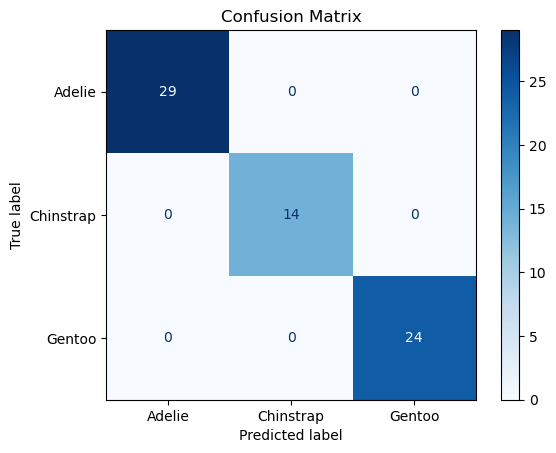

In [46]:
ConfusionMatrixDisplay.from_estimator(
    final_pipeline,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

In [47]:
y_prob = final_pipeline.predict_proba(X_test)

In [48]:
classes = y.unique()

y_test_bin = label_binarize(y_test,classes=classes)

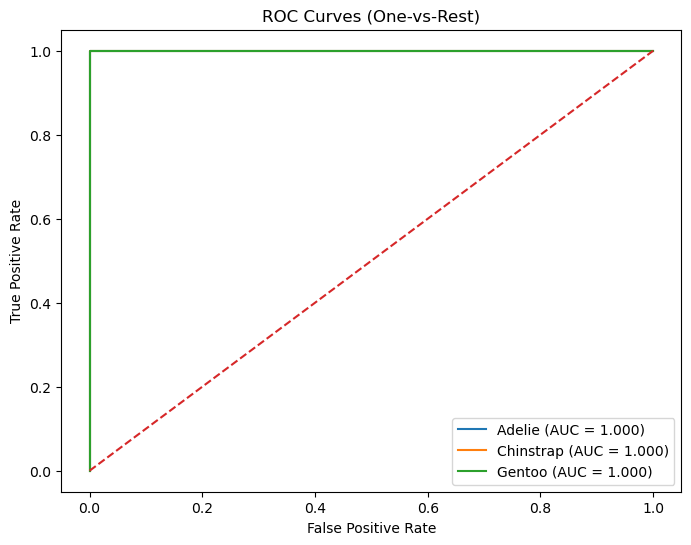

In [49]:
plt.figure(figsize=(8,6))

for i, class_name in enumerate(classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr,tpr,label=f"{class_name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.show()

In [50]:
train_sizes, train_scores, test_scores = learning_curve(
    final_pipeline,

    X,
    y,

    cv=3,
    scoring="f1_macro",
    train_sizes=np.linspace(0.5, 1.0, 6),
    n_jobs=-1
)

In [51]:
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

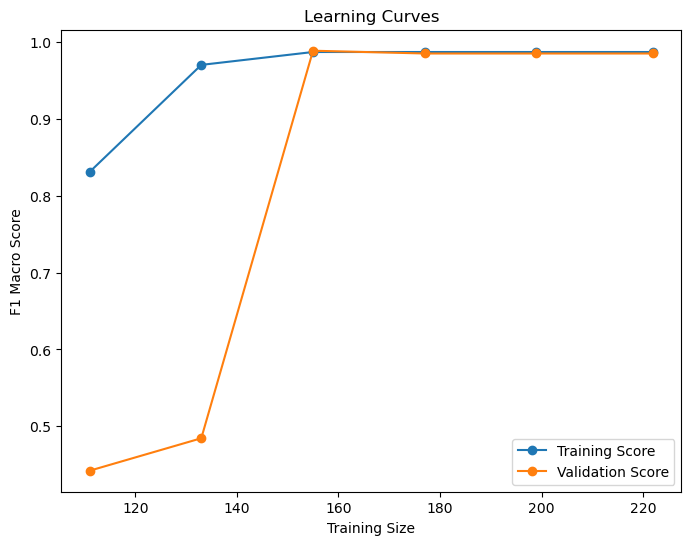

In [52]:
plt.figure(figsize=(8,6))

plt.plot(
    train_sizes,
    train_mean,

    marker="o",

    label="Training Score"
)

plt.plot(
    train_sizes,
    test_mean,

    marker="o",

    label="Validation Score"
)

plt.xlabel("Training Size")
plt.ylabel("F1 Macro Score")
plt.title("Learning Curves")
plt.legend()
plt.show()

In [53]:
perm_importance = permutation_importance(
    final_pipeline,

    X_test,
    y_test,

    n_repeats=10,
    random_state=42
)

In [54]:
feature_names = X.columns
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_importance.importances_mean
})

In [55]:
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head()

,Feature,Importance
1,bill_length_mm,0.241791
2,bill_depth_mm,0.043284
0,island,0.025373
4,body_mass_g,0.020896
3,flipper_length_mm,0.007463


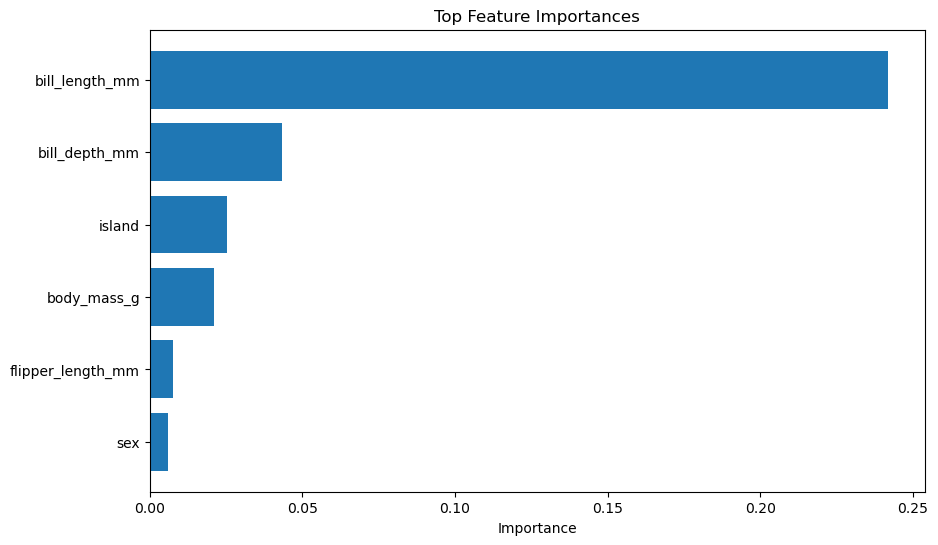

In [56]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top Feature Importances")
plt.show()

### Model Evaluation & Interpretation

The tuned Logistic Regression model achieved very strong classification performance on the held-out test set. Accuracy, precision, recall, and macro F1-scores were all very high, indicating that the model generalized effectively to unseen penguin samples.

The confusion matrix showed that most predictions were classified correctly, with only a very small number of misclassifications. This suggests that the penguin species are highly separable using the available physical measurements.

The ROC curves also demonstrated excellent class separation. The AUC values for all three species were 1.0, meaning the classifier was highly effective at distinguishing between Adelie, Chinstrap, and Gentoo penguins.

The learning curves indicate that the model generalizes very well. As the training size increases, both the training and validation F1 scores converge to very high values close to 0.99.
At smaller training sizes, the validation score is lower because the model has limited data to learn from. However, performance improves rapidly as more training samples are added.
The small gap between the training and validation curves suggests that the model is not significantly overfitting. At the same time, the high scores indicate that the model is also not underfitting.

Overall, the learning curves demonstrate stable and reliable model performance with strong generalization capability.

Permutation importance analysis showed that bill_length_mm was the most influential feature by a large margin. Bill depth, island, and body mass also contributed to predictions, while features such as sex and flipper length had relatively smaller effects. This indicates that bill-related measurements provide the strongest biological separation between penguin species.

There were no major signs of data leakage or evaluation problems. All preprocessing steps, including scaling and one-hot encoding, were applied inside the pipeline, ensuring that transformations were learned only from the training data.

Overall, the model performed exceptionally well because the penguin species form naturally distinct groups in feature space, making the classification task relatively easy for supervised learning algorithms.

# Model Deployment Prototype

1.Serialize the best tuned model (full pipeline including preprocessor) using joblib.dump().

2.Create an app.py file with a Flask /predict endpoint that:

- Loads the serialized pipeline.

- Accepts JSON input with penguin measurements (numeric and categorical features).

- Returns the predicted species and class probabilities.

- Includes basic input validation.

3.Also add a /health endpoint.

4.Test the API from your notebook:

- Send a valid request with sample penguin measurements.

- Send an invalid request and verify error handling.

5.Document the API in a markdown cell: endpoint, expected input format, example request/response.

In [57]:
import joblib

In [58]:
joblib.dump(final_pipeline,"penguin_model.joblib")

['penguin_model.joblib']